In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, training_data, labels):
        self.training_data = training_data
        self.labels = labels

    def predict(self, test_point):
        print(f"\nĐiểm cần dự đoán: {test_point}")

        # Tính khoảng cách Euclid từ điểm cần dự đoán đến tất cả điểm huấn luyện
        distances = np.sqrt(np.sum((self.training_data - test_point)**2, axis=1))
        print(f"\nKhoảng cách Euclid từ test_point đến từng điểm huấn luyện:\n{distances}")

        # Sắp xếp các chỉ số theo khoảng cách tăng dần
        sorted_indices = np.argsort(distances)
        print(f"\nChỉ số sau khi sắp xếp theo khoảng cách tăng dần:\n{sorted_indices}")

        # Lấy nhãn của k điểm gần nhất
        k_nearest_labels = self.labels[sorted_indices][:self.k]
        print(f"\nNhãn của {self.k} điểm gần nhất:\n{k_nearest_labels}")

        # Lấy nhãn xuất hiện nhiều nhất
        most_common = Counter(k_nearest_labels).most_common(1)
        print(f"\nNhãn phổ biến nhất trong {self.k} hàng xóm gần nhất: {most_common[0][0]}")

        return most_common[0][0]

In [ ]:
# 1. Tạo dữ liệu gồm 50 điểm có 2 đặc trưng
X = np.random.rand(50, 2)
# Gán nhãn: nếu tổng 2 đặc trưng > 1 thì nhãn 1, ngược lại nhãn 0
y = ((X[:, 0] + X[:, 1]) > (1 + np.random.uniform(low=-0.2, high=0.2, size=50))).astype(int)

In [ ]:
X_new = np.array([[0.3, 0.8]])

# 3. Khởi tạo và huấn luyện mô hình với các giá trị k khác nhau
knn3 = KNN(k=3)
knn5 = KNN(k=5)
knn7 = KNN(k=7)

knn3.fit(X, y)
knn5.fit(X, y)
knn7.fit(X, y)

# Dự đoán nhãn cho X_new với các giá trị k=3, 5, 7
pred3 = knn3.predict(X_new)
pred5 = knn5.predict(X_new)
pred7 = knn7.predict(X_new)


Điểm cần dự đoán: [[0.3 0.8]]

Khoảng cách Euclid từ test_point đến từng điểm huấn luyện:
[0.25278695 0.08985727 0.26148648 0.29279425 0.33544947 0.38902932
 0.7674083  0.29312064 0.2929712  0.41221151 0.78609289 0.46872597
 0.18983926 0.55100413 0.42864803 0.39284011 0.68758951 0.37912117
 0.5093019  0.15285348 0.72242311 0.24274489 0.53847445 0.07416025
 0.19265746 0.68503282 0.17218001 0.91355291 0.15541935 0.36049601
 0.44761856 0.59914296 0.36288321 0.16833291 0.71338597 0.54053246
 0.78110536 0.36619502 0.359532   0.12920862 0.75702079 0.37508941
 0.6280673  0.32842158 0.71804903 0.22324832 0.11423955 0.50985336
 0.77199525 0.2122609 ]

Chỉ số sau khi sắp xếp theo khoảng cách tăng dần:
[23  1 46 39 19 28 33 26 12 24 49 45 21  0  2  3  8  7 43  4 38 29 32 37
 41 17  5 15  9 14 30 11 18 47 22 35 13 31 42 25 16 34 44 20 40  6 48 36
 10 27]

Nhãn của 3 điểm gần nhất:
[0 1 1]

Nhãn phổ biến nhất trong 3 hàng xóm gần nhất: 1

Điểm cần dự đoán: [[0.3 0.8]]

Khoảng cách Euclid từ test_p

In [ ]:
print("Dự đoán với k=3:", pred3)
print("Dự đoán với k=5:", pred5)
print("Dự đoán với k=7:", pred7)

Dự đoán với k=3: 1
Dự đoán với k=5: 1
Dự đoán với k=7: 1


**If we need to plot a line from (1, 3) to (8, 10), we have to pass two arrays [1, 8] and [3, 10] to the plot function.**

xpoints = np.array([1, 8])
ypoints = np.array([3, 10])

plt.plot(xpoints, ypoints)

23 1 46
23 1 46 39 19
23 1 46 39 19 28 33


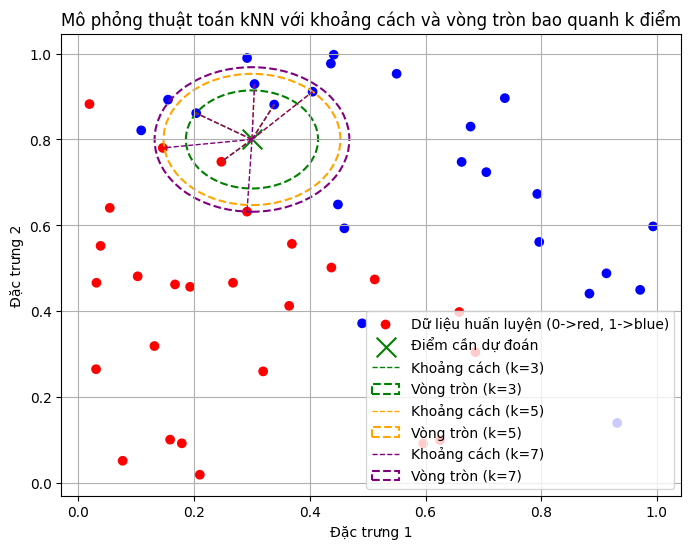

In [ ]:
# 4. Vẽ đồ thị minh họa
plt.figure(figsize=(8, 6))

# Vẽ dữ liệu huấn luyện: nhãn 0 -> đỏ, nhãn 1 -> xanh
colors = ['red' if label == 0 else 'blue' for label in y]
plt.scatter(X[:, 0], X[:, 1], c=colors, label="Dữ liệu huấn luyện (0->red, 1->blue)")

# Vẽ điểm cần dự đoán
plt.scatter(X_new[:, 0], X_new[:, 1], c='green', marker='x', s=200, label="Điểm cần dự đoán")

def annotate_knn(k, color):
    # Tính khoảng cách từ điểm cần dự đoán đến tất cả các điểm huấn luyện
    distances = np.sqrt(np.sum((X - X_new)**2, axis=1))
    sorted_indices = np.argsort(distances)
    # Lấy k điểm gần nhất
    nearest_indices = sorted_indices[:k]
    print(*nearest_indices)
    # Vẽ đường nối từ điểm cần dự đoán đến từng điểm trong k điểm gần nhất
    for i, idx in enumerate(nearest_indices):
        x_neighbor = X[idx]
        plt.plot([X_new[0, 0], x_neighbor[0]], [X_new[0, 1], x_neighbor[1]],
                 color=color, linestyle='--', linewidth=1,
                 label=f"Khoảng cách (k={k})" if i == 0 else "")
    # Vẽ vòng tròn bao quanh k điểm: bán kính bằng khoảng cách xa nhất trong k điểm
    radius = distances[sorted_indices[k - 1]]
    circle = plt.Circle((X_new[0, 0], X_new[0, 1]), radius, color=color,
                        fill=False, linestyle='--', linewidth=1.5,
                        label=f"Vòng tròn (k={k})")
    plt.gca().add_artist(circle)

# Vẽ các đường và vòng tròn cho k=3, 5, 7 với màu khác nhau
annotate_knn(3, 'green')
annotate_knn(5, 'orange')
annotate_knn(7, 'purple')

plt.title("Mô phỏng thuật toán kNN với khoảng cách và vòng tròn bao quanh k điểm")
plt.xlabel("Đặc trưng 1")
plt.ylabel("Đặc trưng 2")
plt.legend()
plt.grid(True)
plt.show()
